In [1]:
###### DotPlot ####
# Load necessary libraries
# Load necessary libraries
library(ggplot2)
library(data.table)
library(dplyr)
library(cowplot)
library(ggridges)
theme_set(theme_cowplot())
#
#setwd("/medpop/esp2/mesbah/projects/Meta_GWAS//MetaGWAS_N900k/GWAMA/gwas_overlap/")
setwd("/medpop/esp2/mesbah/projects/Meta_GWAS//MetaGWAS_N900k/GWAMA/")


Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




# cojo snps

In [2]:
cat("CHIP\n")
chip <- fread("CHIP.cojo.snp.tsv", header=FALSE)
nrow(chip)
chip



CHIP


[1] 36

V1
<chr>
chr1:3380387:T:C
chr1:226389605:C:T
chr2:16088060:T:C
chr2:16446383:A:T
chr2:159925824:T:C
chr3:101417558:G:C
chr3:128484651:AT:A
chr3:138634713:AC:A
chr3:160368930:T:TA


In [7]:
chip$Genes <- c("PRDM16",
               "PARP1",
               "MYCN",
               "CYRIA",
               "LY75", 
               "SENP7",
                "GATA2",
                "PIK3CB",
                "SMC4","SMC4",
                "AFF1", 
                "TET2", "TET2",
                "TERT","TERT","TERT","TERT","TERT","TERT",
                "NOTCH4", 
                "ZNF318", 
                "CD164", "CD164",
                "H2AFV",
                "ATM",
                "ATF7IP", 
                "ITPR2",
                "ATP8B4",
                "TP53/NAA38",
                "MSI2",
                "SETBP1",
                "CEBPA",
                "BCL2L1",
                "RUNX1",
                "CHEK2",
                "ODF3B")





In [8]:
chip$GenVarID <- paste(chip$Genes,chip$V1, sep=" ")
(chip)

V1,Genes,GenVarID
<chr>,<chr>,<chr>
chr1:3380387:T:C,PRDM16,PRDM16 chr1:3380387:T:C
chr1:226389605:C:T,PARP1,PARP1 chr1:226389605:C:T
chr2:16088060:T:C,MYCN,MYCN chr2:16088060:T:C
chr2:16446383:A:T,CYRIA,CYRIA chr2:16446383:A:T
chr2:159925824:T:C,LY75,LY75 chr2:159925824:T:C
chr3:101417558:G:C,SENP7,SENP7 chr3:101417558:G:C
chr3:128484651:AT:A,GATA2,GATA2 chr3:128484651:AT:A
chr3:138634713:AC:A,PIK3CB,PIK3CB chr3:138634713:AC:A
chr3:160368930:T:TA,SMC4,SMC4 chr3:160368930:T:TA


In [9]:
# DNMT3A
cat("DNMT3A\n")
dnmt <- fread("DNMT3A.cojo.snp.tsv", header=FALSE)
nrow(dnmt)
dnmt <- dnmt[dnmt$V1!="chr1:6473468:G:A",]
dnmt
nrow(dnmt)

DNMT3A


[1] 38

V1
<chr>
chr1:226389605:C:T
chr2:16088807:T:C
chr2:16433323:T:TGAA
chr2:66428360:A:G
chr2:159824856:C:CT
chr2:159834145:G:A
chr3:101365760:T:C
chr3:160368930:T:TA
chr3:160412804:T:TTATC


[1] 37

In [10]:
# DNMT3A
dnmt$Genes <- c("PARP1",
"MYCN",
"CYRIA",
"MEIS1",
"LY75","LY75",
"SENP7",
"SMC4","SMC4",
"MECOM",
"TET2","TET2",
"4q25",
"TERT",
"TERT",
"TERT",
"TERT",
"TERT",
"TERT",
"TERT",
"TERT",
"ZNF318",
"CD164", "CD164",
"MYB",
"H2AFV",
"PHF20L1",
"10q23.1",
"STN1",
"ATM",
"ITPR2",
"TCL1A",
"TP53/NAA38",
"MSI2",
"SETBP1",
"PPP5C",
"CHEK2")


In [11]:
dnmt$GenVarID <- paste(dnmt$Genes, dnmt$V1, sep=" ")
(dnmt)

V1,Genes,GenVarID
<chr>,<chr>,<chr>
chr1:226389605:C:T,PARP1,PARP1 chr1:226389605:C:T
chr2:16088807:T:C,MYCN,MYCN chr2:16088807:T:C
chr2:16433323:T:TGAA,CYRIA,CYRIA chr2:16433323:T:TGAA
chr2:66428360:A:G,MEIS1,MEIS1 chr2:66428360:A:G
chr2:159824856:C:CT,LY75,LY75 chr2:159824856:C:CT
chr2:159834145:G:A,LY75,LY75 chr2:159834145:G:A
chr3:101365760:T:C,SENP7,SENP7 chr3:101365760:T:C
chr3:160368930:T:TA,SMC4,SMC4 chr3:160368930:T:TA
chr3:160412804:T:TTATC,SMC4,SMC4 chr3:160412804:T:TTATC


In [13]:
cat("TET2\n")
tet <- fread("TET2.cojo.snp.tsv", header=FALSE)
nrow(tet)
tet
tet <- tet[(tet$V1 %in% c("chr1:229376149:A:T",  "chr2:238000798:A:G", "chr3:24301839:T:C",
  "chr3:128616009:C:T", "chr3:160436959:A:G", "chr4:187053674:C:T",
  "chr5:1104823:C:T", "chr5:1285859:C:A", "chr5:1287079:G:A",
  "chr8:132824187:C:T", "chr10:18119237:G:GT", "chr11:62844507:G:A",
  "chr11:108306370:T:A", "chr13:40940299:C:CAGA", "chr13:50517843:T:C",
  "chr14:95713905:C:A", "chr17:52883522:A:C", "chr17:65721342:A:G") ),]
tet
nrow(tet)

TET2


[1] 27

V1
<chr>
chr1:229376149:A:T
chr2:238000798:A:G
chr3:24301839:T:C
chr3:128616009:C:T
chr3:135367870:G:T
chr3:160436959:A:G
chr3:192410035:G:A
chr4:187053674:C:T
chr5:1104823:C:T


V1
<chr>
chr1:229376149:A:T
chr2:238000798:A:G
chr3:24301839:T:C
chr3:128616009:C:T
chr3:160436959:A:G
chr4:187053674:C:T
chr5:1104823:C:T
chr5:1285859:C:A
chr5:1287079:G:A


[1] 18

In [14]:
# TET2
tet$Genes <- c("CCSAP/ACTA1",
"UBE2F",
"THRB",
"RPN1/GATA2",
"SMC4",
"FAT1",
"TERT","TERT","TERT",
"PHF20L1",
"CACNB2",
"WDR74",
"ATM",
"ELF1",
"DLEU7",
"TCL1A",
"CA10",
"CEP112")


In [15]:
tet$GenVarID <- paste(tet$Genes, tet$V1, sep=" ")
(tet)

V1,Genes,GenVarID
<chr>,<chr>,<chr>
chr1:229376149:A:T,CCSAP/ACTA1,CCSAP/ACTA1 chr1:229376149:A:T
chr2:238000798:A:G,UBE2F,UBE2F chr2:238000798:A:G
chr3:24301839:T:C,THRB,THRB chr3:24301839:T:C
chr3:128616009:C:T,RPN1/GATA2,RPN1/GATA2 chr3:128616009:C:T
chr3:160436959:A:G,SMC4,SMC4 chr3:160436959:A:G
chr4:187053674:C:T,FAT1,FAT1 chr4:187053674:C:T
chr5:1104823:C:T,TERT,TERT chr5:1104823:C:T
chr5:1285859:C:A,TERT,TERT chr5:1285859:C:A
chr5:1287079:G:A,TERT,TERT chr5:1287079:G:A


In [ ]:
chip_dnmt_tet <- fread("uniq.cojo.SNP_list.tsv", header=FALSE)
nrow(chip_dnmt_tet)
length(unique(c(chip$V1, dnmt$V1, tet$V1)))

# Meta-GWAS Files

In [6]:
system("ls out/*.out.gz| head -2 ", intern = TRUE)
system("zcat out/*.out.gz| head -2 ", intern = TRUE)

[1] "out/GWAMA.chr1_22.hasASXL1.AFR.AoU250k_TOPMed72k_MGBB53k.noukbb.out.gz"  
[2] "out/GWAMA.chr1_22.hasASXL1.AFR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.gz"

[1] "rs_number\treference_allele\tother_allele\teaf\tbeta\tse\tbeta_95L\tbeta_95U\tz\tp-value\t_-log10_p-value\tq_statistic\tq_p-value\ti2\tn_studies\tn_samples\teffects"
[2] "chr1:13273:G:C\tC\tG\t0.036554\t-0.519919\t0.430168\t-1.363048\t0.323210\t-1.208642\t0.226780\t0.644395\t0.000000\t1.000000\t-nan\t1\t42882\t-??"

In [18]:
# gwas_header <- fread("zcat out/*.gz | head -1", head=TRUE, sep="\t")
gwas_header <- fread("zcat out/GWAMA.chr1_22.hasASXL1.AFR.AoU250k_TOPMed72k_MGBB53k.noukbb.out.gz | head -1", head=TRUE, sep="\t")
gwas_header
names(gwas_header)

rs_number,reference_allele,other_allele,eaf,beta,se,beta_95L,beta_95U,z,p-value,_-log10_p-value,q_statistic,q_p-value,i2,n_studies,n_samples,effects
<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


[1] "rs_number"        "reference_allele" "other_allele"     "eaf"             
 [5] "beta"             "se"               "beta_95L"         "beta_95U"        
 [9] "z"                "p-value"          "_-log10_p-value"  "q_statistic"     
[13] "q_p-value"        "i2"               "n_studies"        "n_samples"       
[17] "effects"

In [19]:
 c("SNPID", "EA", "OtherA", "EAF", "BETA", "SE", "BETA_95L", "BETA_95U", "Z", "P", "min_neg_log10", "Q_stat", "Q_P", "I2", "N_studies", "N","Direction")

[1] "SNPID"         "EA"            "OtherA"        "EAF"          
 [5] "BETA"          "SE"            "BETA_95L"      "BETA_95U"     
 [9] "Z"             "P"             "min_neg_log10" "Q_stat"       
[13] "Q_P"           "I2"            "N_studies"     "N"            
[17] "Direction"

In [7]:
system("ls gwas_overlap/*.out.tsv| grep MultiANC.ukbb200k_ ", intern = TRUE)

[1] "gwas_overlap/overlap_sr53.GWAMA.chr1_22.hasCH.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv"             
 [2] "gwas_overlap/overlap_sr54.GWAMA.chr1_22.hasDNMT3A.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv"         
 [3] "gwas_overlap/overlap_sr55.GWAMA.chr1_22.hasCHvaf10.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv"        
 [4] "gwas_overlap/overlap_sr56.GWAMA.chr1_22.hasTET2.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv"           
 [5] "gwas_overlap/overlap_sr57.GWAMA.chr1_22.hasASXL1.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv"          
 [6] "gwas_overlap/overlap_sr58.GWAMA.chr1_22.hasDDR.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv"            
 [7] "gwas_overlap/overlap_sr59.GWAMA.chr1_22.hasSF.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv"             
 [8] "gwas_overlap/overlap_sr61.GWAMA.chr1_22.hasCH.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv"    
 [9] "gwas_overlap/overlap_sr64.GWAMA.chr1_22.hasDNMT3A.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv"
[10] "gwas_overlap/overlap_sr66.GWAMA.chr1_22.hasTET2.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv"

In [7]:
system("ls gwas_overlap/*.out.tsv| grep -E 'EUR.ukb|AFR.ukb|AMR.ukb|Male.ukb|Female.ukb' ", intern = TRUE)

[1] "gwas_overlap/overlap_sr18.GWAMA.chr1_22.hasCH.AMR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"             
 [2] "gwas_overlap/overlap_sr19.GWAMA.chr1_22.hasCH.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"            
 [3] "gwas_overlap/overlap_sr20.GWAMA.chr1_22.hasCH.AFR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"             
 [4] "gwas_overlap/overlap_sr21.GWAMA.chr1_22.hasCHvaf10.AMR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"        
 [5] "gwas_overlap/overlap_sr22.GWAMA.chr1_22.hasCHvaf10.AFR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"        
 [6] "gwas_overlap/overlap_sr23.GWAMA.chr1_22.hasCH.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"          
 [7] "gwas_overlap/overlap_sr24.GWAMA.chr1_22.hasCHvaf10.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"     
 [8] "gwas_overlap/overlap_sr25.GWAMA.chr1_22.hasCH.EUR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"             
 [9] "gwas_overlap/overlap_sr26.GWAMA.chr1_22.hasDNMT3A.AFR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"         
[10] "gwas_overlap/overlap_sr27.GWAMA.chr1_22.hasCHvaf10.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"       
[11] "gwas_overlap/overlap_sr28.GWAMA.chr1_22.hasDNMT3A.AMR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"         
[12] "gwas_overlap/overlap_sr29.GWAMA.chr1_22.hasDNMT3A.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"        
[13] "gwas_overlap/overlap_sr30.GWAMA.chr1_22.hasDNMT3A.EUR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"         
[14] "gwas_overlap/overlap_sr31.GWAMA.chr1_22.hasDNMT3A.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"      
[15] "gwas_overlap/overlap_sr32.GWAMA.chr1_22.hasTET2.AMR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"           
[16] "gwas_overlap/overlap_sr33.GWAMA.chr1_22.hasTET2.AFR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"           
[17] "gwas_overlap/overlap_sr34.GWAMA.chr1_22.hasASXL1.AMR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"          
[18] "gwas_overlap/overlap_sr35.GWAMA.chr1_22.hasTET2.EUR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"           
[19] "gwas_overlap/overlap_sr36.GWAMA.chr1_22.hasASXL1.AFR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"          
[20] "gwas_overlap/overlap_sr37.GWAMA.chr1_22.hasSF.AFR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"             
[21] "gwas_overlap/overlap_sr38.GWAMA.chr1_22.hasTET2.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"        
[22] "gwas_overlap/overlap_sr39.GWAMA.chr1_22.hasTET2.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"          
[23] "gwas_overlap/overlap_sr40.GWAMA.chr1_22.hasASXL1.EUR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"          
[24] "gwas_overlap/overlap_sr41.GWAMA.chr1_22.hasASXL1.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"         
[25] "gwas_overlap/overlap_sr42.GWAMA.chr1_22.hasASXL1.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"       
[26] "gwas_overlap/overlap_sr43.GWAMA.chr1_22.hasSF.AMR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"             
[27] "gwas_overlap/overlap_sr44.GWAMA.chr1_22.hasDDR.AMR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"            
[28] "gwas_overlap/overlap_sr45.GWAMA.chr1_22.hasDDR.AFR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"            
[29] "gwas_overlap/overlap_sr46.GWAMA.chr1_22.hasSF.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"          
[30] "gwas_overlap/overlap_sr47.GWAMA.chr1_22.hasSF.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"            
[31] "gwas_overlap/overlap_sr48.GWAMA.chr1_22.hasDDR.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"           
[32] "gwas_overlap/overlap_sr49.GWAMA.chr1_22.hasDDR.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"         
[33] "gwas_overlap/overlap_sr50.GWAMA.chr1_22.hasCH.EUR.ukbb450k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv"    
[34] "gwas_overlap/overlap_sr51.GWAMA.chr1_22.hasDNMT3A.EUR.ukbb450k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv"
[35] "gwas_overlap/overlap_sr52.GWAMA.chr1_22.hasTET2.EUR.ukbb450k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv"

In [8]:
system("head gwas_overlap/overlap_sr64.GWAMA.chr1_22.hasDNMT3A.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv", intern = T)

[1] "chr1:3380387:T:C\tC\tT\t0.654272\t0.032474\t0.009800\t0.013265\t0.051683\t3.313537\t9.26E-04\t3.033274\t3.714331\t0.591233\t0.000000\t6\t816596\t+++-++"        
 [2] "chr1:6473468:G:A\tA\tG\t0.000918\t0.772762\t0.143233\t0.492026\t1.053498\t5.395147\t7.00E-08\t7.154776\t2.913420\t0.572417\t0.000000\t5\t762373\t+++++?"        
 [3] "chr1:226389605:C:T\tT\tC\t0.155161\t-0.146148\t0.013649\t-0.172900\t-0.119396\t-10.707588\t1.01E-26\t25.995791\t5.476477\t0.241805\t0.269603\t5\t762393\t-----?"
 [4] "chr1:229376149:A:T\tT\tA\t0.001401\t-0.146671\t0.148077\t-0.436902\t0.143561\t-0.990502\t0.321916\t0.492257\t1.118709\t0.891293\t0.000000\t5\t762300\t+---+?"   
 [5] "chr2:16088060:T:C\tC\tT\t0.648433\t0.060539\t0.009737\t0.041455\t0.079623\t6.217588\t5.21E-10\t9.283554\t1.721705\t0.886154\t0.000000\t6\t816614\t++++++"       
 [6] "chr2:16088807:T:C\tC\tT\t0.649711\t0.060341\t0.009723\t0.041285\t0.079398\t6.206280\t5.59E-10\t9.252343\t1.643870\t0.895894\t0.000000\t6\t816604\t++++++"       
 [7] "chr2:16433323:T:TGAA\tTGAA\tT\t0.769800\t0.070124\t0.011352\t0.047875\t0.092373\t6.177461\t6.71E-10\t9.173045\t0.035772\t0.999987\t0.000000\t6\t816618\t++++++" 
 [8] "chr2:16446383:A:T\tT\tA\t0.730036\t0.060987\t0.010729\t0.039959\t0.082015\t5.684496\t1.35E-08\t7.871103\t0.168367\t0.996649\t0.000000\t5\t761962\t+++++?"       
 [9] "chr2:66428360:A:G\tG\tA\t0.632191\t-0.060661\t0.009688\t-0.079649\t-0.041672\t-6.261288\t3.94E-10\t9.404681\t5.539623\t0.353621\t0.097411\t6\t813788\t-----+"   
[10] "chr2:159824856:C:CT\tCT\tC\t0.845873\t0.097987\t0.012948\t0.072609\t0.123365\t7.567792\t3.97E-14\t13.401426\t11.694112\t0.039228\t0.572434\t6\t816622\t+++++-"

# Overall CHIP vs. others

In [4]:
library(data.table)

# Vector of file paths:
multiCH_list <- c(
  'gwas_overlap/overlap_sr61.GWAMA.chr1_22.hasCH.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv',
  'gwas_overlap/overlap_sr55.GWAMA.chr1_22.hasCHvaf10.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
  'gwas_overlap/overlap_sr64.GWAMA.chr1_22.hasDNMT3A.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv',
  'gwas_overlap/overlap_sr66.GWAMA.chr1_22.hasTET2.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv',
  'gwas_overlap/overlap_sr57.GWAMA.chr1_22.hasASXL1.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
  'gwas_overlap/overlap_sr58.GWAMA.chr1_22.hasDDR.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
  'gwas_overlap/overlap_sr59.GWAMA.chr1_22.hasSF.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv'
)

# (Optional) Define a matching vector of 'traits' for each file
traits <- c(
  "CHIP",
  "Expanded CHIP",
  "DNMT3A",
  "TET2",
  "ASXL1",
  "DNA Damage Response",
  "Splicing Factors"
)

# Make a skeleton data frame with the proper columns:
chip_overlap <- data.frame(
  SNPID     = character(),
  EA        = character(),
  OtherA    = character(),
  EAF       = numeric(),
  BETA      = numeric(),
  SE        = numeric(),
  BETA_95L  = numeric(),
  BETA_95U  = numeric(),
  Z         = numeric(),
  P         = numeric(),
  min_neg_log10 = numeric(),
  Q_stat    = numeric(),
  Q_P       = numeric(),
  I2        = numeric(),
  N_studies = numeric(),
  N         = numeric(),
  Direction = character(),
  Trait     = character(),
  stringsAsFactors = FALSE
)

# Loop over each file in multiCH_list
for (i in seq_along(multiCH_list)) {
  
  cat("Reading file:", multiCH_list[i], "\n")
  d <- fread(multiCH_list[i], header = FALSE, sep = "\t")
  
  # Assign column names to match your specification
  names(d) <- c(
    "SNPID", "EA", "OtherA", "EAF", "BETA", "SE", "BETA_95L", "BETA_95U",
    "Z", "P", "min_neg_log10", "Q_stat", "Q_P", "I2", "N_studies", "N", 
    "Direction"
  )
  
  # Add a 'Trait' column, if you have a traits vector
  # (Remove or replace if not using a separate traits vector)
  if (exists("traits") && length(traits) == length(multiCH_list)) {
    d$Trait <- traits[i]
  } else {
    d$Trait <- NA
  }
  
  # rbind the data
  chip_overlap <- rbind(chip_overlap, d)
  
  cat("Current rows in chip_overlap:", nrow(chip_overlap), "\n\n")
}

# Check the structure
str(chip_overlap)


Reading file: gwas_overlap/overlap_sr61.GWAMA.chr1_22.hasCH.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv 
Current rows in chip_overlap: 88 

Reading file: gwas_overlap/overlap_sr55.GWAMA.chr1_22.hasCHvaf10.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv 
Current rows in chip_overlap: 176 

Reading file: gwas_overlap/overlap_sr64.GWAMA.chr1_22.hasDNMT3A.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv 
Current rows in chip_overlap: 264 

Reading file: gwas_overlap/overlap_sr66.GWAMA.chr1_22.hasTET2.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.out.tsv 
Current rows in chip_overlap: 352 

Reading file: gwas_overlap/overlap_sr57.GWAMA.chr1_22.hasASXL1.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv 
Current rows in chip_overlap: 440 

Reading file: gwas_overlap/overlap_sr58.GWAMA.chr1_22.hasDDR.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.out.tsv 
Current rows in chip_overlap: 528 

Reading file: gwa

In [5]:
table(chip_overlap$Trait, exclude = NULL)


              ASXL1                CHIP DNA Damage Response              DNMT3A 
                 88                  88                  88                  88 
      Expanded CHIP    Splicing Factors                TET2 
                 88                  88                  88 

# Dotplot CHIP vs. other traits

In [18]:
chip_only <- merge(chip_overlap, chip, by.x="SNPID", by.y="V1")
str(chip_only)
head(chip_only)

Classes 'data.table' and 'data.frame':	252 obs. of  20 variables:
 $ SNPID        : chr  "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" ...
 $ EA           : chr  "G" "G" "G" "G" ...
 $ OtherA       : chr  "A" "A" "A" "A" ...
 $ EAF          : num  0.4 0.398 0.399 0.397 0.397 ...
 $ BETA         : num  0.07091 0.06711 0.09939 0.09636 0.00281 ...
 $ SE           : num  0.00698 0.0094 0.00934 0.01555 0.02292 ...
 $ BETA_95L     : num  0.0572 0.0487 0.0811 0.0659 -0.0421 ...
 $ BETA_95U     : num  0.0846 0.0855 0.1177 0.1268 0.0477 ...
 $ Z            : num  10.163 7.137 10.637 6.196 0.123 ...
 $ P            : num  3.12e-24 9.95e-13 2.15e-26 5.96e-10 9.02e-01 ...
 $ min_neg_log10: num  23.5058 12.0022 25.6669 9.2251 0.0446 ...
 $ Q_stat       : num  9.55 6.37 12.35 5.43 1.54 ...
 $ Q_P          : num  0.0891 0.1731 0.0303 0.2461 0.819 ...
 $ I2           : num  0.476 0.372 0.595 0.263 0 ...
 $ N_studies    : int  6 5 6 5 5 5 5 6 5 6 ...
 $ N      

SNPID,EA,OtherA,EAF,BETA,SE,BETA_95L,BETA_95U,Z,P,min_neg_log10,Q_stat,Q_P,I2,N_studies,N,Direction,Trait,Genes,GenVarID
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr11:108174268:A:G,G,A,0.399552,0.070911,0.006978,0.057235,0.084587,10.162612,3.12000e-24,23.505813,9.546681,0.089147,0.476258,6,838539,++++++,CHIP,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.398031,0.067114,0.009404,0.048682,0.085546,7.136680,9.95000e-13,12.002159,6.371536,0.173067,0.372208,5,778776,+++++,Expanded CHIP,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.399131,0.099390,0.009344,0.081077,0.117704,10.637182,2.15000e-26,25.666910,12.351283,0.030279,0.595184,6,816383,++++-+,DNMT3A,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.397194,0.096356,0.015550,0.065877,0.126834,6.196384,5.96000e-10,9.225073,5.428223,0.246111,0.263111,5,745996,+++++?,TET2,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.396859,0.002812,0.022915,-0.042101,0.047725,0.122723,9.02306e-01,0.044646,1.543247,0.818954,0.000000,5,741069,-++--,ASXL1,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.396695,-0.146869,0.027276,-0.200329,-0.093409,-5.384654,7.42000e-08,7.129461,12.562913,0.013621,0.681602,5,739878,-----,DNA Damage Response,ATM,ATM chr11:108174268:A:G


In [19]:
# Create a column for color based on p-value thresholds  ####
chip_only$color <- factor(ifelse(chip_only$P<5e-15,
                          "<5e-15", 
                          ifelse(chip_only$P<5e-8 & chip_only$P>=5e-15,
                                 "<5e-8", 
                                 ifelse(chip_only$P<5e-6 & chip_only$P>=5e-8,
                                 "<5e-6", ">5e-6")) ))
                          
# # Create a column for shape based on direction
chip_only$shape <- ifelse(chip_only$Z>0, 24, 25)  # 24 = upfaced triangle, 25 = downfaced triangle
chip_only$direction <- ifelse(chip_only$Z>0, "+", "-")  # 
#chip_only$shape <- ifelse(chip_only$direction == "+", 24, 25)  # 24 = upfaced triangle, 25 = downfaced triangle
head(chip_only)

SNPID,EA,OtherA,EAF,BETA,SE,BETA_95L,BETA_95U,Z,P,...,I2,N_studies,N,Direction,Trait,Genes,GenVarID,color,shape,direction
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>
chr11:108174268:A:G,G,A,0.399552,0.070911,0.006978,0.057235,0.084587,10.162612,3.12000e-24,...,0.476258,6,838539,++++++,CHIP,ATM,ATM chr11:108174268:A:G,<5e-15,24,+
chr11:108174268:A:G,G,A,0.398031,0.067114,0.009404,0.048682,0.085546,7.136680,9.95000e-13,...,0.372208,5,778776,+++++,Expanded CHIP,ATM,ATM chr11:108174268:A:G,<5e-8,24,+
chr11:108174268:A:G,G,A,0.399131,0.099390,0.009344,0.081077,0.117704,10.637182,2.15000e-26,...,0.595184,6,816383,++++-+,DNMT3A,ATM,ATM chr11:108174268:A:G,<5e-15,24,+
chr11:108174268:A:G,G,A,0.397194,0.096356,0.015550,0.065877,0.126834,6.196384,5.96000e-10,...,0.263111,5,745996,+++++?,TET2,ATM,ATM chr11:108174268:A:G,<5e-8,24,+
chr11:108174268:A:G,G,A,0.396859,0.002812,0.022915,-0.042101,0.047725,0.122723,9.02306e-01,...,0.000000,5,741069,-++--,ASXL1,ATM,ATM chr11:108174268:A:G,>5e-6,24,+
chr11:108174268:A:G,G,A,0.396695,-0.146869,0.027276,-0.200329,-0.093409,-5.384654,7.42000e-08,...,0.681602,5,739878,-----,DNA Damage Response,ATM,ATM chr11:108174268:A:G,<5e-6,25,-


In [20]:
table(chip_only$color, exclude = NULL)
table(chip_only$P<5e-15)
summary(scale(chip_only$Z))


<5e-15  <5e-6  <5e-8  >5e-6 
    39     24     48    141 


FALSE  TRUE 
  213    39 

       V1          
 Min.   :-4.18026  
 1st Qu.:-0.55678  
 Median :-0.01013  
 Mean   : 0.00000  
 3rd Qu.: 0.60864  
 Max.   : 4.29265  

In [70]:
names(chip_only)

[1] "SNPID"         "EA"            "OtherA"        "EAF"          
 [5] "BETA"          "SE"            "BETA_95L"      "BETA_95U"     
 [9] "Z"             "P"             "min_neg_log10" "Q_stat"       
[13] "Q_P"           "I2"            "N_studies"     "N"            
[17] "Direction"     "Trait"         "Genes"         "GenVarID"     
[21] "color"         "shape"         "direction"

In [21]:
unique(chip_only$SNPID)

[1] "chr11:108174268:A:G" "chr12:14479323:C:T"  "chr12:26437841:G:A" 
 [4] "chr15:50235004:AG:A" "chr17:57388410:C:T"  "chr17:7877391:G:T"  
 [7] "chr18:44569779:G:A"  "chr19:33259704:C:T"  "chr1:226389605:C:T" 
[10] "chr1:3380387:T:C"    "chr20:31681257:G:A"  "chr21:34971255:C:T" 
[13] "chr22:28695868:AG:A" "chr22:50532618:T:C"  "chr2:159925824:T:C" 
[16] "chr2:16088060:T:C"   "chr2:16446383:A:T"   "chr3:101417558:G:C" 
[19] "chr3:128484651:AT:A" "chr3:138634713:AC:A" "chr3:160368930:T:TA"
[22] "chr3:160419960:A:T"  "chr4:104812818:A:G"  "chr4:104884951:A:T" 
[25] "chr4:87087630:G:A"   "chr5:1113385:G:A"    "chr5:1279913:G:A"   
[28] "chr5:1285859:C:A"    "chr5:1287079:G:A"    "chr5:1292003:G:A"   
[31] "chr5:1293274:C:G"    "chr6:109280500:G:C"  "chr6:109384228:C:A" 
[34] "chr6:32197667:A:G"   "chr6:43381570:A:C"   "chr7:44877441:A:G"

In [15]:
# chip_only$Trait <- ordered(chip_only$Trait,
  #                         levels = c("CHIP","Expanded CHIP","DNMT3A",
   #                                   "TET2","ASXL1",
    #                                  "DNA Damage Response","Splicing Factors"))

# str(chip_only)
# str(chip_only$Trait)

Classes 'data.table' and 'data.frame':	252 obs. of  23 variables:
 $ SNPID        : chr  "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" ...
 $ EA           : chr  "G" "G" "G" "G" ...
 $ OtherA       : chr  "A" "A" "A" "A" ...
 $ EAF          : num  0.4 0.398 0.399 0.397 0.397 ...
 $ BETA         : num  0.07091 0.06711 0.09939 0.09636 0.00281 ...
 $ SE           : num  0.00698 0.0094 0.00934 0.01555 0.02292 ...
 $ BETA_95L     : num  0.0572 0.0487 0.0811 0.0659 -0.0421 ...
 $ BETA_95U     : num  0.0846 0.0855 0.1177 0.1268 0.0477 ...
 $ Z            : num  10.163 7.137 10.637 6.196 0.123 ...
 $ P            : num  3.12e-24 9.95e-13 2.15e-26 5.96e-10 9.02e-01 ...
 $ min_neg_log10: num  23.5058 12.0022 25.6669 9.2251 0.0446 ...
 $ Q_stat       : num  9.55 6.37 12.35 5.43 1.54 ...
 $ Q_P          : num  0.0891 0.1731 0.0303 0.2461 0.819 ...
 $ I2           : num  0.476 0.372 0.595 0.263 0 ...
 $ N_studies    : int  6 5 6 5 5 5 5 6 5 6 ...
 $ N      

In [22]:
chip_only$Trait <- ordered(chip_only$Trait,
                           levels = c("Splicing Factors", "DNA Damage Response","ASXL1","TET2","DNMT3A","Expanded CHIP","CHIP"))

 str(chip_only)
 str(chip_only$Trait)

Classes 'data.table' and 'data.frame':	252 obs. of  23 variables:
 $ SNPID        : chr  "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" ...
 $ EA           : chr  "G" "G" "G" "G" ...
 $ OtherA       : chr  "A" "A" "A" "A" ...
 $ EAF          : num  0.4 0.398 0.399 0.397 0.397 ...
 $ BETA         : num  0.07091 0.06711 0.09939 0.09636 0.00281 ...
 $ SE           : num  0.00698 0.0094 0.00934 0.01555 0.02292 ...
 $ BETA_95L     : num  0.0572 0.0487 0.0811 0.0659 -0.0421 ...
 $ BETA_95U     : num  0.0846 0.0855 0.1177 0.1268 0.0477 ...
 $ Z            : num  10.163 7.137 10.637 6.196 0.123 ...
 $ P            : num  3.12e-24 9.95e-13 2.15e-26 5.96e-10 9.02e-01 ...
 $ min_neg_log10: num  23.5058 12.0022 25.6669 9.2251 0.0446 ...
 $ Q_stat       : num  9.55 6.37 12.35 5.43 1.54 ...
 $ Q_P          : num  0.0891 0.1731 0.0303 0.2461 0.819 ...
 $ I2           : num  0.476 0.372 0.595 0.263 0 ...
 $ N_studies    : int  6 5 6 5 5 5 5 6 5 6 ...
 $ N      

In [23]:
chip$GenVarID

[1] "PRDM16 chr1:3380387:T:C"    "PARP1 chr1:226389605:C:T"  
 [3] "MYCN chr2:16088060:T:C"     "CYRIA chr2:16446383:A:T"   
 [5] "LY75 chr2:159925824:T:C"    "SENP7 chr3:101417558:G:C"  
 [7] "GATA2 chr3:128484651:AT:A"  "PIK3CB chr3:138634713:AC:A"
 [9] "SMC4 chr3:160368930:T:TA"   "SMC4 chr3:160419960:A:T"   
[11] "AFF1 chr4:87087630:G:A"     "TET2 chr4:104812818:A:G"   
[13] "TET2 chr4:104884951:A:T"    "TERT chr5:1113385:G:A"     
[15] "TERT chr5:1279913:G:A"      "TERT chr5:1285859:C:A"     
[17] "TERT chr5:1287079:G:A"      "TERT chr5:1292003:G:A"     
[19] "TERT chr5:1293274:C:G"      "NOTCH4 chr6:32197667:A:G"  
[21] "ZNF318 chr6:43381570:A:C"   "CD164 chr6:109280500:G:C"  
[23] "CD164 chr6:109384228:C:A"   "H2AFV chr7:44877441:A:G"   
[25] "ATM chr11:108174268:A:G"    "ATF7IP chr12:14479323:C:T" 
[27] "ITPR2 chr12:26437841:G:A"   "ATP8B4 chr15:50235004:AG:A"
[29] "NAA38 chr17:7877391:G:T"    "MSI2 chr17:57388410:C:T"   
[31] "SETBP1 chr18:44569779:G:A"  "CEBPA chr19:33259704:C:T"  
[33] "BCL2L1 chr20:31681257:G:A"  "RUNX1 chr21:34971255:C:T"  
[35] "CHEK2 chr22:28695868:AG:A"  "ODF3B chr22:50532618:T:C"

In [24]:
chip_only$GenVarID <- ordered(chip_only$GenVarID,
                           levels = chip$GenVarID)

str(chip_only)

Classes 'data.table' and 'data.frame':	252 obs. of  23 variables:
 $ SNPID        : chr  "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" ...
 $ EA           : chr  "G" "G" "G" "G" ...
 $ OtherA       : chr  "A" "A" "A" "A" ...
 $ EAF          : num  0.4 0.398 0.399 0.397 0.397 ...
 $ BETA         : num  0.07091 0.06711 0.09939 0.09636 0.00281 ...
 $ SE           : num  0.00698 0.0094 0.00934 0.01555 0.02292 ...
 $ BETA_95L     : num  0.0572 0.0487 0.0811 0.0659 -0.0421 ...
 $ BETA_95U     : num  0.0846 0.0855 0.1177 0.1268 0.0477 ...
 $ Z            : num  10.163 7.137 10.637 6.196 0.123 ...
 $ P            : num  3.12e-24 9.95e-13 2.15e-26 5.96e-10 9.02e-01 ...
 $ min_neg_log10: num  23.5058 12.0022 25.6669 9.2251 0.0446 ...
 $ Q_stat       : num  9.55 6.37 12.35 5.43 1.54 ...
 $ Q_P          : num  0.0891 0.1731 0.0303 0.2461 0.819 ...
 $ I2           : num  0.476 0.372 0.595 0.263 0 ...
 $ N_studies    : int  6 5 6 5 5 5 5 6 5 6 ...
 $ N      

In [25]:
chip_only$Trait
chip_only$GenVarID

[1] CHIP                Expanded CHIP       DNMT3A             
  [4] TET2                ASXL1               DNA Damage Response
  [7] Splicing Factors    CHIP                Expanded CHIP      
 [10] DNMT3A              TET2                ASXL1              
 [13] DNA Damage Response Splicing Factors    CHIP               
 [16] Expanded CHIP       DNMT3A              TET2               
 [19] ASXL1               DNA Damage Response Splicing Factors   
 [22] CHIP                Expanded CHIP       DNMT3A             
 [25] TET2                ASXL1               DNA Damage Response
 [28] Splicing Factors    CHIP                Expanded CHIP      
 [31] DNMT3A              TET2                ASXL1              
 [34] DNA Damage Response Splicing Factors    CHIP               
 [37] Expanded CHIP       DNMT3A              TET2               
 [40] ASXL1               DNA Damage Response Splicing Factors   
 [43] CHIP                Expanded CHIP       DNMT3A             
 [46] TET2                ASXL1               DNA Damage Response
 [49] Splicing Factors    CHIP                Expanded CHIP      
 [52] DNMT3A              TET2                ASXL1              
 [55] DNA Damage Response Splicing Factors    CHIP               
 [58] Expanded CHIP       DNMT3A              TET2               
 [61] ASXL1               DNA Damage Response Splicing Factors   
 [64] CHIP                Expanded CHIP       DNMT3A             
 [67] TET2                ASXL1               DNA Damage Response
 [70] Splicing Factors    CHIP                Expanded CHIP      
 [73] DNMT3A              TET2                ASXL1              
 [76] DNA Damage Response Splicing Factors    CHIP               
 [79] Expanded CHIP       DNMT3A              TET2               
 [82] ASXL1               DNA Damage Response Splicing Factors   
 [85] CHIP                Expanded CHIP       DNMT3A             
 [88] TET2                ASXL1               DNA Damage Response
 [91] Splicing Factors    CHIP                Expanded CHIP      
 [94] DNMT3A              TET2                ASXL1              
 [97] DNA Damage Response Splicing Factors    CHIP               
[100] Expanded CHIP       DNMT3A              TET2               
[103] ASXL1               DNA Damage Response Splicing Factors   
[106] CHIP                Expanded CHIP       DNMT3A             
[109] TET2                ASXL1               DNA Damage Response
[112] Splicing Factors    CHIP                Expanded CHIP      
[115] DNMT3A              TET2                ASXL1              
[118] DNA Damage Response Splicing Factors    CHIP               
[121] Expanded CHIP       DNMT3A              TET2               
[124] ASXL1               DNA Damage Response Splicing Factors   
[127] CHIP                Expanded CHIP       DNMT3A             
[130] TET2                ASXL1               DNA Damage Response
[133] Splicing Factors    CHIP                Expanded CHIP      
[136] DNMT3A              TET2                ASXL1              
[139] DNA Damage Response Splicing Factors    CHIP               
[142] Expanded CHIP       DNMT3A              TET2               
[145] ASXL1               DNA Damage Response Splicing Factors   
[148] CHIP                Expanded CHIP       DNMT3A             
[151] TET2                ASXL1               DNA Damage Response
[154] Splicing Factors    CHIP                Expanded CHIP      
[157] DNMT3A              TET2                ASXL1              
[160] DNA Damage Response Splicing Factors    CHIP               
[163] Expanded CHIP       DNMT3A              TET2               
[166] ASXL1               DNA Damage Response Splicing Factors   
[169] CHIP                Expanded CHIP       DNMT3A             
[172] TET2                ASXL1               DNA Damage Response
[175] Splicing Factors    CHIP                Expanded CHIP      
[178] DNMT3A              TET2                ASXL1              
[181] DNA Damage Response Splicing Factors

[1] ATM chr11:108174268:A:G    ATM chr11:108174268:A:G   
  [3] ATM chr11:108174268:A:G    ATM chr11:108174268:A:G   
  [5] ATM chr11:108174268:A:G    ATM chr11:108174268:A:G   
  [7] ATM chr11:108174268:A:G    ATF7IP chr12:14479323:C:T 
  [9] ATF7IP chr12:14479323:C:T  ATF7IP chr12:14479323:C:T 
 [11] ATF7IP chr12:14479323:C:T  ATF7IP chr12:14479323:C:T 
 [13] ATF7IP chr12:14479323:C:T  ATF7IP chr12:14479323:C:T 
 [15] ITPR2 chr12:26437841:G:A   ITPR2 chr12:26437841:G:A  
 [17] ITPR2 chr12:26437841:G:A   ITPR2 chr12:26437841:G:A  
 [19] ITPR2 chr12:26437841:G:A   ITPR2 chr12:26437841:G:A  
 [21] ITPR2 chr12:26437841:G:A   ATP8B4 chr15:50235004:AG:A
 [23] ATP8B4 chr15:50235004:AG:A ATP8B4 chr15:50235004:AG:A
 [25] ATP8B4 chr15:50235004:AG:A ATP8B4 chr15:50235004:AG:A
 [27] ATP8B4 chr15:50235004:AG:A ATP8B4 chr15:50235004:AG:A
 [29] MSI2 chr17:57388410:C:T    MSI2 chr17:57388410:C:T   
 [31] MSI2 chr17:57388410:C:T    MSI2 chr17:57388410:C:T   
 [33] MSI2 chr17:57388410:C:T    MSI2 chr17:57388410:C:T   
 [35] MSI2 chr17:57388410:C:T    NAA38 chr17:7877391:G:T   
 [37] NAA38 chr17:7877391:G:T    NAA38 chr17:7877391:G:T   
 [39] NAA38 chr17:7877391:G:T    NAA38 chr17:7877391:G:T   
 [41] NAA38 chr17:7877391:G:T    NAA38 chr17:7877391:G:T   
 [43] SETBP1 chr18:44569779:G:A  SETBP1 chr18:44569779:G:A 
 [45] SETBP1 chr18:44569779:G:A  SETBP1 chr18:44569779:G:A 
 [47] SETBP1 chr18:44569779:G:A  SETBP1 chr18:44569779:G:A 
 [49] SETBP1 chr18:44569779:G:A  CEBPA chr19:33259704:C:T  
 [51] CEBPA chr19:33259704:C:T   CEBPA chr19:33259704:C:T  
 [53] CEBPA chr19:33259704:C:T   CEBPA chr19:33259704:C:T  
 [55] CEBPA chr19:33259704:C:T   CEBPA chr19:33259704:C:T  
 [57] PARP1 chr1:226389605:C:T   PARP1 chr1:226389605:C:T  
 [59] PARP1 chr1:226389605:C:T   PARP1 chr1:226389605:C:T  
 [61] PARP1 chr1:226389605:C:T   PARP1 chr1:226389605:C:T  
 [63] PARP1 chr1:226389605:C:T   PRDM16 chr1:3380387:T:C   
 [65] PRDM16 chr1:3380387:T:C    PRDM16 chr1:3380387:T:C   
 [67] PRDM16 chr1:3380387:T:C    PRDM16 chr1:3380387:T:C   
 [69] PRDM16 chr1:3380387:T:C    PRDM16 chr1:3380387:T:C   
 [71] BCL2L1 chr20:31681257:G:A  BCL2L1 chr20:31681257:G:A 
 [73] BCL2L1 chr20:31681257:G:A  BCL2L1 chr20:31681257:G:A 
 [75] BCL2L1 chr20:31681257:G:A  BCL2L1 chr20:31681257:G:A 
 [77] BCL2L1 chr20:31681257:G:A  RUNX1 chr21:34971255:C:T  
 [79] RUNX1 chr21:34971255:C:T   RUNX1 chr21:34971255:C:T  
 [81] RUNX1 chr21:34971255:C:T   RUNX1 chr21:34971255:C:T  
 [83] RUNX1 chr21:34971255:C:T   RUNX1 chr21:34971255:C:T  
 [85] CHEK2 chr22:28695868:AG:A  CHEK2 chr22:28695868:AG:A 
 [87] CHEK2 chr22:28695868:AG:A  CHEK2 chr22:28695868:AG:A 
 [89] CHEK2 chr22:28695868:AG:A  CHEK2 chr22:28695868:AG:A 
 [91] CHEK2 chr22:28695868:AG:A  ODF3B chr22:50532618:T:C  
 [93] ODF3B chr22:50532618:T:C   ODF3B chr22:50532618:T:C  
 [95] ODF3B chr22:50532618:T:C   ODF3B chr22:50532618:T:C  
 [97] ODF3B chr22:50532618:T:C   ODF3B chr22:50532618:T:C  
 [99] LY75 chr2:159925824:T:C    LY75 chr2:159925824:T:C   
[101] LY75 chr2:159925824:T:C    LY75 chr2:159925824:T:C   
[103] LY75 chr2:159925824:T:C    LY75 chr2:159925824:T:C   
[105] LY75 chr2:159925824:T:C    MYCN chr2:16088060:T:C    
[107] MYCN chr2:16088060:T:C     MYCN chr2:16088060:T:C    
[109] MYCN chr2:16088060:T:C     MYCN chr2:16088060:T:C    
[111] MYCN chr2:16088060:T:C     MYCN chr2:16088060:T:C    
[113] CYRIA chr2:16446383:A:T    CYRIA chr2:16446383:A:T   
[115] CYRIA chr2:16446383:A:T    CYRIA chr2:16446383:A:T   
[117] CYRIA chr2:16446383:A:T    CYRIA chr2:16446383:A:T   
[119] CYRIA chr2:16446383:A:T    SENP7 chr3:101417558:G:C  
[121] SENP7 chr3:101417558:G:C   SENP7 chr3:101417558:G:C  
[123] SENP7 chr3:101417558:G:C   SENP7 chr3:101417558:G:C  
[125] SENP7 chr3:101417558:G:C   SENP7 chr3:101417558:G:C  
[127] GATA2 chr3:128484651:AT:A  GATA2 chr3:128484651:AT:A 
[129] GATA2 chr3:128484651:AT:A  GATA2 chr3:128484651:AT:A 
[131] GATA2 chr3:128484651:AT:A  GATA2 chr3:128484651:AT:A 
[133] GATA2 chr3:128484651:AT:A  PIK3CB ch

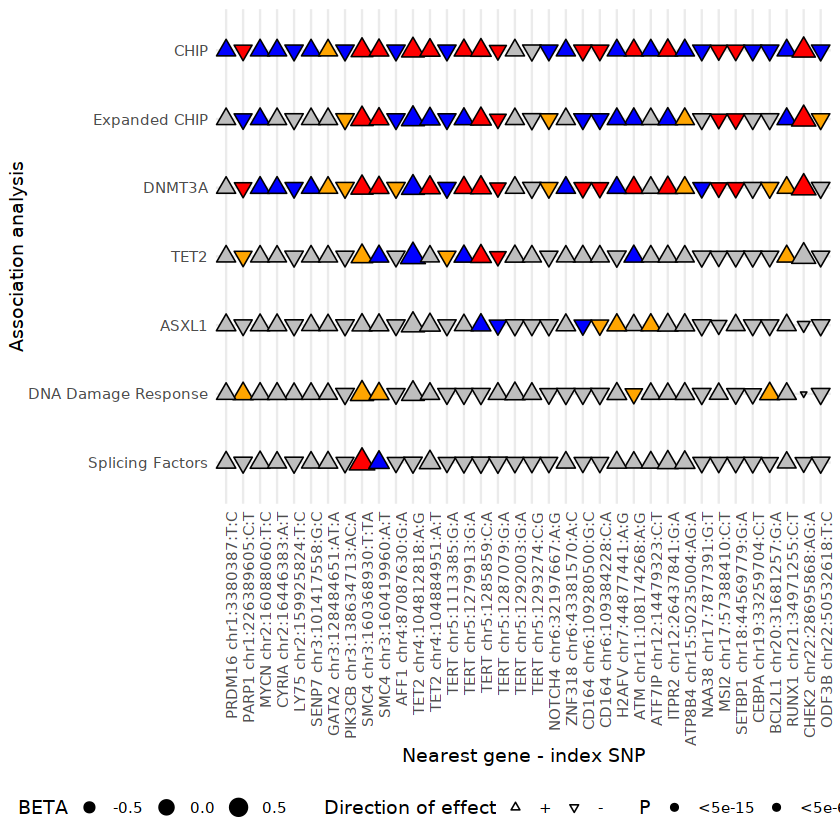

In [26]:
# Create the dot plot   ####
ggplot(chip_only, aes(x = GenVarID, y = Trait)) +
  geom_point(aes(size = BETA, 
                 fill = color, 
                 shape = direction)) +  # Map shape to `direction`
  scale_fill_manual(values = c("<5e-15" = "red", 
                               "<5e-8" = "blue", 
                               "<5e-6" = "orange", 
                               ">5e-6" = "grey")) +
  scale_size_continuous(range = c(1, 5)) +
  scale_shape_manual(values = c("+" = 24, "-" = 25)) +  # "+" for upfacing triangle, "-" for downfacing triangle
  theme_minimal() +
  labs(
    x = "Nearest gene - index SNP",
    y = "Association analysis",
    size = "BETA",
    fill = "P",
    shape = "Direction of effect"
  ) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "bottom"
  )



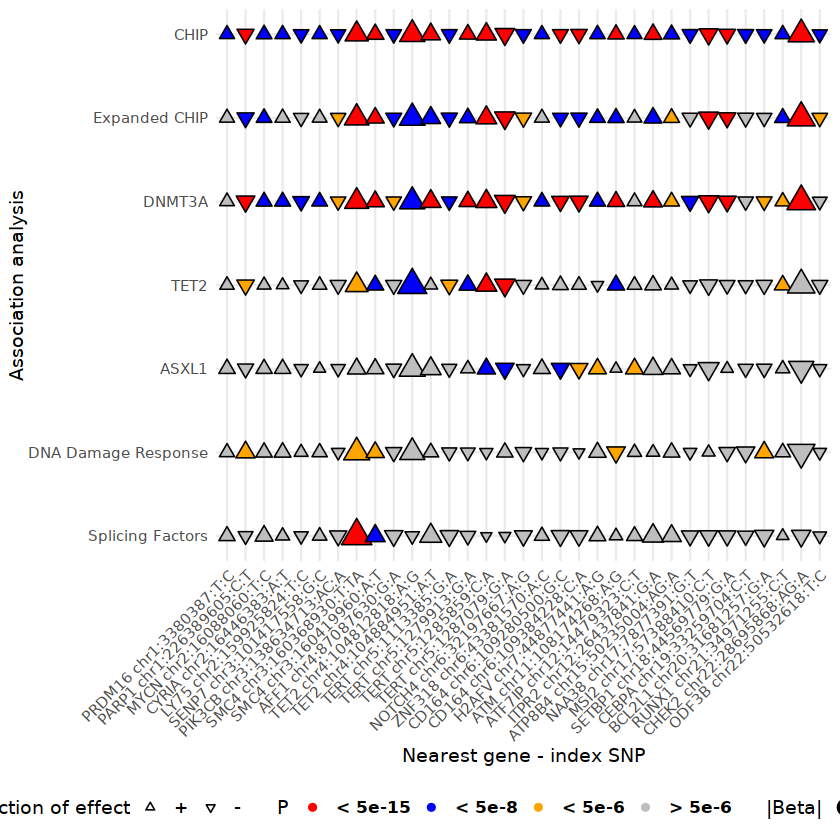

In [27]:
#-------- plot
p5e8_snvs <- unique(chip_only$SNPID[chip_only$P<=5e-8])
chip_only.p5e8 <- chip_only %>% 
  filter(SNPID %in% p5e8_snvs) 

# pdf(file = "multiCHIP_vs_others.MCPS.pc.pdf", width = 12, height = 12)
# png(file = "multiCHIP_vs_others.MCPS.pc.png", 
  #  width = 12, height = 12, units= "in", 
   # res=300, pointsize = 4)

  ggplot(chip_only.p5e8, aes(x = GenVarID, y = Trait)) +
  geom_point(
    aes(
      size  = abs(BETA),        # size by absolute value of BETA
      fill  = color,            # factor with categories: "<5e-15", "<5e-8", etc.
      shape = direction         # "+" or "-" for triangles up/down
    ),
    color = "black"
  ) +
  # Manually define fill scale:
  scale_fill_manual(
    name = "P",
    breaks = c("<5e-15", "<5e-8", "<5e-6", ">5e-6"),
    values = c("<5e-15" = "red", 
               "<5e-8"  = "blue", 
               "<5e-6"  = "orange", 
               ">5e-6"  = "grey"),
    labels = c(
      "<5e-15" = "< 5e-15",
      "<5e-8"  = "< 5e-8",
      "<5e-6"  = "< 5e-6",
      ">5e-6"  = "> 5e-6"
    ),
    guide = guide_legend(override.aes = list(color = c("red", "blue", "orange", "grey")))
  ) +
  scale_size_continuous(
    name  = "|Beta|",
    range = c(2,6)
  ) +
  scale_shape_manual(
    name   = "Direction of effect",
    values = c("+" = 24, "-" = 25)
  ) +
  labs(
    x = "Nearest gene - index SNP",
    y = "Association analysis"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.text = element_text(size = 10, face = "bold")
  ) + # Reduce vertical spacing between rows (y-axis categories)
    scale_y_discrete(expand = expansion(mult = c(0.05, 0.05)))

# dev.off()


In [28]:
pdf(file = "multiCHIP_vs_others.pdf", width = 12, height = 12)
# Create the dot plot   ####
 ggplot(chip_only, aes(x = GenVarID, y = Trait)) +
  geom_point(
    aes(
      size  = abs(BETA),        # size by absolute value of BETA
      fill  = color,            # factor with categories: "<5e-15", "<5e-8", etc.
      shape = direction         # "+" or "-" for triangles up/down
    ),
    color = "black"
  ) +
  # Manually define fill scale:
  scale_fill_manual(
    name = "P",
    breaks = c("<5e-15", "<5e-8", "<5e-6", ">5e-6"),
    values = c("<5e-15" = "red", 
               "<5e-8"  = "blue", 
               "<5e-6"  = "orange", 
               ">5e-6"  = "grey"),
    labels = c(
      "<5e-15" = "< 5e-15",
      "<5e-8"  = "< 5e-8",
      "<5e-6"  = "< 5e-6",
      ">5e-6"  = "> 5e-6"
    ),
    guide = guide_legend(override.aes = list(color = c("red", "blue", "orange", "grey")))
  ) +
  scale_size_continuous(
    name  = "|Beta|",
    range = c(2,6)
  ) +
  scale_shape_manual(
    name   = "Direction of effect",
    values = c("+" = 24, "-" = 25)
  ) +
  labs(
    x = "Nearest gene - index SNP",
    y = "Association analysis"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.text = element_text(size = 10, face = "bold")
  ) + # Reduce vertical spacing between rows (y-axis categories)
    scale_y_discrete(expand = expansion(mult = c(0.05, 0.05)))


dev.off()

png 
  2

In [29]:
library(ggplot2)

# 1. Ensure 'color' is a factor with the levels you intend to plot
chip_only$color <- factor(
  chip_only$color,
  levels = c("<5e-15", "<5e-8", "<5e-6", ">5e-6")
)

#pdf(file = "multiCHIP_vs_others.v2.pdf", width = 12, height = 12)
png(file = "multiCHIP_vs_others.v2.png", width = 12, height = 12, units= "in", res=300, pointsize = 4)
# Create the dot plot
 ggplot(chip_only, aes(x = GenVarID, y = Trait)) +
  geom_point(
    aes(
      size  = abs(BETA),        # size by absolute value of BETA
      fill  = color,            # factor with categories: "<5e-15", "<5e-8", etc.
      shape = direction         # "+" or "-" for triangles up/down
    ),
    color = "black"
  ) +
  # Manually define fill scale:
  scale_fill_manual(
    name = "P",
    breaks = c("<5e-15", "<5e-8", "<5e-6", ">5e-6"),
    values = c("<5e-15" = "red", 
               "<5e-8"  = "blue", 
               "<5e-6"  = "orange", 
               ">5e-6"  = "grey"),
    labels = c(
      "<5e-15" = "< 5e-15",
      "<5e-8"  = "< 5e-8",
      "<5e-6"  = "< 5e-6",
      ">5e-6"  = "> 5e-6"
    ),
    guide = guide_legend(override.aes = list(color = c("red", "blue", "orange", "grey")))
  ) +
  scale_size_continuous(
    name  = "|Beta|",
    range = c(2,6)
  ) +
  scale_shape_manual(
    name   = "Direction of effect",
    values = c("+" = 24, "-" = 25)
  ) +
  labs(
    x = "Nearest gene - index SNP",
    y = "Association analysis"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.text = element_text(size = 10, face = "bold")
  ) + # Reduce vertical spacing between rows (y-axis categories)
    scale_y_discrete(expand = expansion(mult = c(0.05, 0.05)))
dev.off()

png 
  2

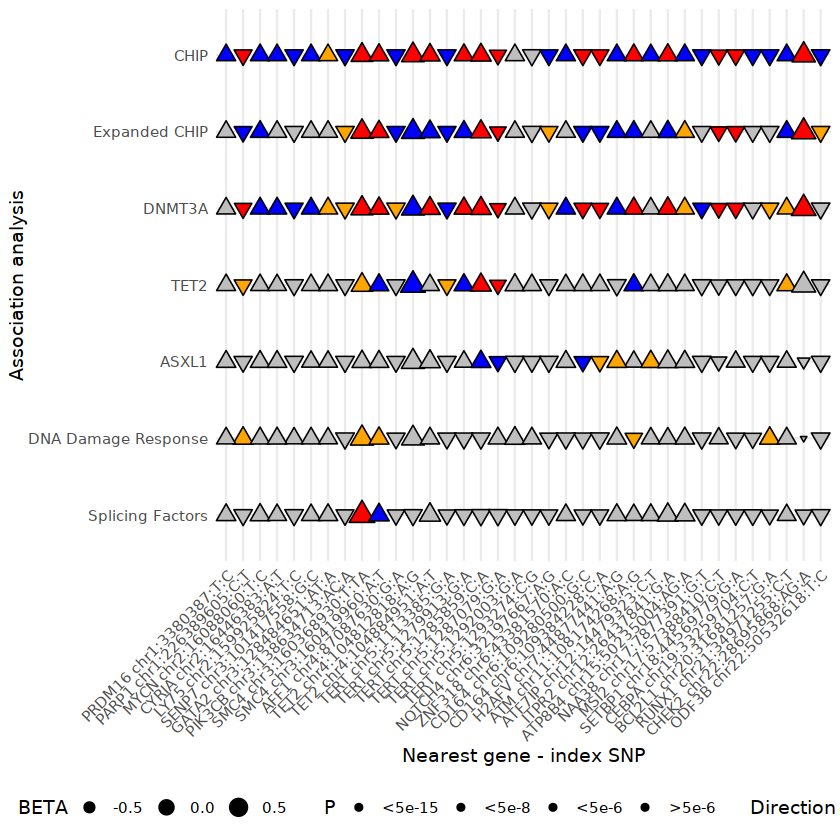

In [94]:
ggplot(chip_only, aes(x = GenVarID, y = Trait)) +
  geom_point(
    aes(
      size  = BETA, 
      fill  = color,      # Map fill to the 'color' factor
      shape = direction   # '+' or '-' for triangles up/down
    ),
    color = "black"       # Outline color for the shape
  ) +
  # Discrete fill scale for P-value categories
  scale_fill_manual(
    name = "P",           # Legend title for fill
    values = c(
      "<5e-15" = "red", 
      "<5e-8"  = "blue", 
      "<5e-6"  = "orange", 
      ">5e-6"  = "grey"
    ),
    breaks = c("<5e-15", "<5e-8", "<5e-6", ">5e-6"),  
    drop = FALSE  # Keep categories even if no points in some bin
  ) +
  # Map BETA to size
  scale_size_continuous(range = c(1, 5)) +
  # Discrete shape scale for direction
  scale_shape_manual(
    name = "Direction of effect",
    values = c("+" = 24, "-" = 25)  # Up/down triangles
  ) +
  labs(
    x    = "Nearest gene - index SNP",
    y    = "Association analysis",
    size = "BETA"    # The size legend label
    # No need to specify fill= or shape= here,
    # we handle those in the scale_*_manual() calls
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

# Overall CHIP vs other Traits
* Multi-ancestry with MCPS Meta-GWAS

In [7]:
system("ls gwas_overlap/mcps/*.out.tsv| grep MultiANC ", intern = TRUE)

[1] "gwas_overlap/mcps/overlap_sr13.GWAMA.chr1_22.hasDDR.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_tp53MCPS136k.out.tsv"        
[2] "gwas_overlap/mcps/overlap_sr14.GWAMA.chr1_22.hasDNMT3A.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k_MCPS136k.out.tsv"
[3] "gwas_overlap/mcps/overlap_sr15.GWAMA.chr1_22.hasCH.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k_MCPS136k.out.tsv"    
[4] "gwas_overlap/mcps/overlap_sr16.GWAMA.chr1_22.hasASXL1.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_MCPS136k.out.tsv"          
[5] "gwas_overlap/mcps/overlap_sr17.GWAMA.chr1_22.hasTET2.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k_MCPS136k.out.tsv"  
[6] "gwas_overlap/mcps/overlap_sr18.GWAMA.chr1_22.hasSF.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_MCPS136k.out.tsv"

In [30]:
library(data.table)

# Vector of file paths:
# multiCH_list <- system("ls gwas_overlap/mcps/*.out.tsv| grep MultiANC ", intern = TRUE)
multiCH_list <- c('gwas_overlap/mcps/overlap_sr15.GWAMA.chr1_22.hasCH.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k_MCPS136k.out.tsv',
                 'gwas_overlap/mcps/overlap_sr14.GWAMA.chr1_22.hasDNMT3A.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k_MCPS136k.out.tsv',
                 'gwas_overlap/mcps/overlap_sr17.GWAMA.chr1_22.hasTET2.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k_MCPS136k.out.tsv',
                 'gwas_overlap/mcps/overlap_sr16.GWAMA.chr1_22.hasASXL1.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_MCPS136k.out.tsv',
                 'gwas_overlap/mcps/overlap_sr13.GWAMA.chr1_22.hasDDR.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_tp53MCPS136k.out.tsv',
                 'gwas_overlap/mcps/overlap_sr18.GWAMA.chr1_22.hasSF.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_MCPS136k.out.tsv')
# (Optional) Define a matching vector of 'traits' for each file
traits <- c(
  "CHIP",
  "DNMT3A",
  "TET2",
  "ASXL1",
  "DNA Damage Response",
  "Splicing Factors"
)

# Make a skeleton data frame with the proper columns:
chip_overlap <- data.frame(
  SNPID     = character(),
  EA        = character(),
  OtherA    = character(),
  EAF       = numeric(),
  BETA      = numeric(),
  SE        = numeric(),
  BETA_95L  = numeric(),
  BETA_95U  = numeric(),
  Z         = numeric(),
  P         = numeric(),
  min_neg_log10 = numeric(),
  Q_stat    = numeric(),
  Q_P       = numeric(),
  I2        = numeric(),
  N_studies = numeric(),
  N         = numeric(),
  Direction = character(),
  Trait     = character(),
  stringsAsFactors = FALSE
)

# Loop over each file in multiCH_list
for (i in seq_along(multiCH_list)) {
  
  cat(traits[i],"\n")  
  cat("Reading file:", multiCH_list[i], "\n")
  
  d <- fread(multiCH_list[i], header = FALSE, sep = "\t")
  
  # Assign column names to match your specification
  names(d) <- c(
    "SNPID", "EA", "OtherA", "EAF", "BETA", "SE", "BETA_95L", "BETA_95U",
    "Z", "P", "min_neg_log10", "Q_stat", "Q_P", "I2", "N_studies", "N", 
    "Direction"
  )
  
  # Add a 'Trait' column, if you have a traits vector
  # (Remove or replace if not using a separate traits vector)
  if (exists("traits") && length(traits) == length(multiCH_list)) {
    d$Trait <- traits[i]
  } else {
    d$Trait <- NA
  }
  
  # rbind the data
  chip_overlap <- rbind(chip_overlap, d)
  
  cat("Current rows in chip_overlap:", nrow(chip_overlap), "\n\n")
}

# Check the structure
str(chip_overlap)

table(chip_overlap$Trait)

CHIP 
Reading file: gwas_overlap/mcps/overlap_sr15.GWAMA.chr1_22.hasCH.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k_MCPS136k.out.tsv 
Current rows in chip_overlap: 88 

DNMT3A 
Reading file: gwas_overlap/mcps/overlap_sr14.GWAMA.chr1_22.hasDNMT3A.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k_MCPS136k.out.tsv 
Current rows in chip_overlap: 176 

TET2 
Reading file: gwas_overlap/mcps/overlap_sr17.GWAMA.chr1_22.hasTET2.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k_MCPS136k.out.tsv 
Current rows in chip_overlap: 264 

ASXL1 
Reading file: gwas_overlap/mcps/overlap_sr16.GWAMA.chr1_22.hasASXL1.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_MCPS136k.out.tsv 
Current rows in chip_overlap: 352 

DNA Damage Response 
Reading file: gwas_overlap/mcps/overlap_sr13.GWAMA.chr1_22.hasDDR.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_tp53MCPS136k.out.tsv 
Current rows in chip_overlap: 440 

Splicing Factors 
Reading file: gwas_overlap/mcps/overlap


              ASXL1                CHIP DNA Damage Response              DNMT3A 
                 88                  88                  88                  88 
   Splicing Factors                TET2 
                 88                  88 

In [31]:
table(chip_overlap$Trait)


              ASXL1                CHIP DNA Damage Response              DNMT3A 
                 88                  88                  88                  88 
   Splicing Factors                TET2 
                 88                  88 

In [23]:
ls()

[1] "chip"          "chip_dnmt_tet" "chip_overlap"  "d"            
[5] "dnmt"          "i"             "multiCH_list"  "tet"          
[9] "traits"

In [32]:
chip_only <- merge(chip_overlap, chip, by.x="SNPID", by.y="V1")
str(chip_only)
head(chip_only)

# Create a column for color based on p-value thresholds  ####
chip_only$color <- factor(ifelse(chip_only$P<5e-15,
                          "<5e-15", 
                          ifelse(chip_only$P<5e-8 & chip_only$P>=5e-15,
                                 "<5e-8", 
                                 ifelse(chip_only$P<5e-6 & chip_only$P>=5e-8,
                                 "<5e-6", ">5e-6")) ))
                          
# # Create a column for shape based on direction
chip_only$shape <- ifelse(chip_only$Z>0, 24, 25)  # 24 = upfaced triangle, 25 = downfaced triangle
chip_only$direction <- ifelse(chip_only$Z>0, "+", "-")  # 
#chip_only$shape <- ifelse(chip_only$direction == "+", 24, 25)  # 24 = upfaced triangle, 25 = downfaced triangle
head(chip_only)

chip_only$Trait <- ordered(chip_only$Trait,
                           levels = c("Splicing Factors", "DNA Damage Response", 
                                      "ASXL1","TET2","DNMT3A","CHIP"))

 str(chip_only)
 str(chip_only$Trait)

## 
chip_only$GenVarID <- ordered(chip_only$GenVarID,
                           levels = chip$GenVarID)

str(chip_only)


Classes 'data.table' and 'data.frame':	216 obs. of  20 variables:
 $ SNPID        : chr  "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" ...
 $ EA           : chr  "G" "G" "G" "G" ...
 $ OtherA       : chr  "A" "A" "A" "A" ...
 $ EAF          : num  0.429 0.43 0.431 0.431 0.43 ...
 $ BETA         : num  0.0715 0.0966 0.0909 0.0392 -0.0189 ...
 $ SE           : num  0.0067 0.00869 0.01301 0.01649 0.01792 ...
 $ BETA_95L     : num  0.05837 0.07951 0.06542 0.00683 -0.05399 ...
 $ BETA_95U     : num  0.0846 0.1136 0.1164 0.0715 0.0162 ...
 $ Z            : num  10.68 11.1 6.99 2.37 -1.05 ...
 $ P            : num  1.38e-26 1.29e-28 2.90e-12 1.76e-02 2.92e-01 ...
 $ min_neg_log10: num  25.86 27.889 11.537 1.754 0.535 ...
 $ Q_stat       : num  9.63 13.04 5.84 6.76 51.29 ...
 $ Q_P          : num  1.41e-01 4.24e-02 3.23e-01 2.39e-01 7.55e-10 ...
 $ I2           : num  0.377 0.54 0.143 0.261 0.903 ...
 $ N_studies    : int  7 7 6 6 6 6 7 7 6 6 ...
 $ N 

SNPID,EA,OtherA,EAF,BETA,SE,BETA_95L,BETA_95U,Z,P,min_neg_log10,Q_stat,Q_P,I2,N_studies,N,Direction,Trait,Genes,GenVarID
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr11:108174268:A:G,G,A,0.429461,0.071492,0.006695,0.058370,0.084614,10.678629,1.38000e-26,25.860259,9.633929,1.40939e-01,0.377201,7,974940,+++++++,CHIP,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.429796,0.096555,0.008695,0.079512,0.113598,11.104232,1.29000e-28,27.888507,13.038647,4.24260e-02,0.539830,7,952784,++++-++,DNMT3A,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.430604,0.090918,0.013011,0.065416,0.116419,6.987785,2.90000e-12,11.537319,5.835947,3.22511e-01,0.143241,6,882397,+++++?+,TET2,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.430509,0.039158,0.016493,0.006831,0.071484,2.374199,1.76090e-02,1.754273,6.763178,2.38857e-01,0.260703,6,877470,-++--+,ASXL1,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.430416,-0.018877,0.017915,-0.053990,0.016235,-1.053749,2.91981e-01,0.534645,51.288713,7.55000e-10,0.902513,6,876279,-----+,DNA Damage Response,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.430575,0.058937,0.019824,0.020081,0.097793,2.972939,2.96000e-03,2.528682,4.760880,4.45754e-01,0.000000,6,875032,--++++,Splicing Factors,ATM,ATM chr11:108174268:A:G


SNPID,EA,OtherA,EAF,BETA,SE,BETA_95L,BETA_95U,Z,P,...,I2,N_studies,N,Direction,Trait,Genes,GenVarID,color,shape,direction
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>
chr11:108174268:A:G,G,A,0.429461,0.071492,0.006695,0.058370,0.084614,10.678629,1.38000e-26,...,0.377201,7,974940,+++++++,CHIP,ATM,ATM chr11:108174268:A:G,<5e-15,24,+
chr11:108174268:A:G,G,A,0.429796,0.096555,0.008695,0.079512,0.113598,11.104232,1.29000e-28,...,0.539830,7,952784,++++-++,DNMT3A,ATM,ATM chr11:108174268:A:G,<5e-15,24,+
chr11:108174268:A:G,G,A,0.430604,0.090918,0.013011,0.065416,0.116419,6.987785,2.90000e-12,...,0.143241,6,882397,+++++?+,TET2,ATM,ATM chr11:108174268:A:G,<5e-8,24,+
chr11:108174268:A:G,G,A,0.430509,0.039158,0.016493,0.006831,0.071484,2.374199,1.76090e-02,...,0.260703,6,877470,-++--+,ASXL1,ATM,ATM chr11:108174268:A:G,>5e-6,24,+
chr11:108174268:A:G,G,A,0.430416,-0.018877,0.017915,-0.053990,0.016235,-1.053749,2.91981e-01,...,0.902513,6,876279,-----+,DNA Damage Response,ATM,ATM chr11:108174268:A:G,>5e-6,25,-
chr11:108174268:A:G,G,A,0.430575,0.058937,0.019824,0.020081,0.097793,2.972939,2.96000e-03,...,0.000000,6,875032,--++++,Splicing Factors,ATM,ATM chr11:108174268:A:G,>5e-6,24,+


Classes 'data.table' and 'data.frame':	216 obs. of  23 variables:
 $ SNPID        : chr  "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" ...
 $ EA           : chr  "G" "G" "G" "G" ...
 $ OtherA       : chr  "A" "A" "A" "A" ...
 $ EAF          : num  0.429 0.43 0.431 0.431 0.43 ...
 $ BETA         : num  0.0715 0.0966 0.0909 0.0392 -0.0189 ...
 $ SE           : num  0.0067 0.00869 0.01301 0.01649 0.01792 ...
 $ BETA_95L     : num  0.05837 0.07951 0.06542 0.00683 -0.05399 ...
 $ BETA_95U     : num  0.0846 0.1136 0.1164 0.0715 0.0162 ...
 $ Z            : num  10.68 11.1 6.99 2.37 -1.05 ...
 $ P            : num  1.38e-26 1.29e-28 2.90e-12 1.76e-02 2.92e-01 ...
 $ min_neg_log10: num  25.86 27.889 11.537 1.754 0.535 ...
 $ Q_stat       : num  9.63 13.04 5.84 6.76 51.29 ...
 $ Q_P          : num  1.41e-01 4.24e-02 3.23e-01 2.39e-01 7.55e-10 ...
 $ I2           : num  0.377 0.54 0.143 0.261 0.903 ...
 $ N_studies    : int  7 7 6 6 6 6 7 7 6 6 ...
 $ N 

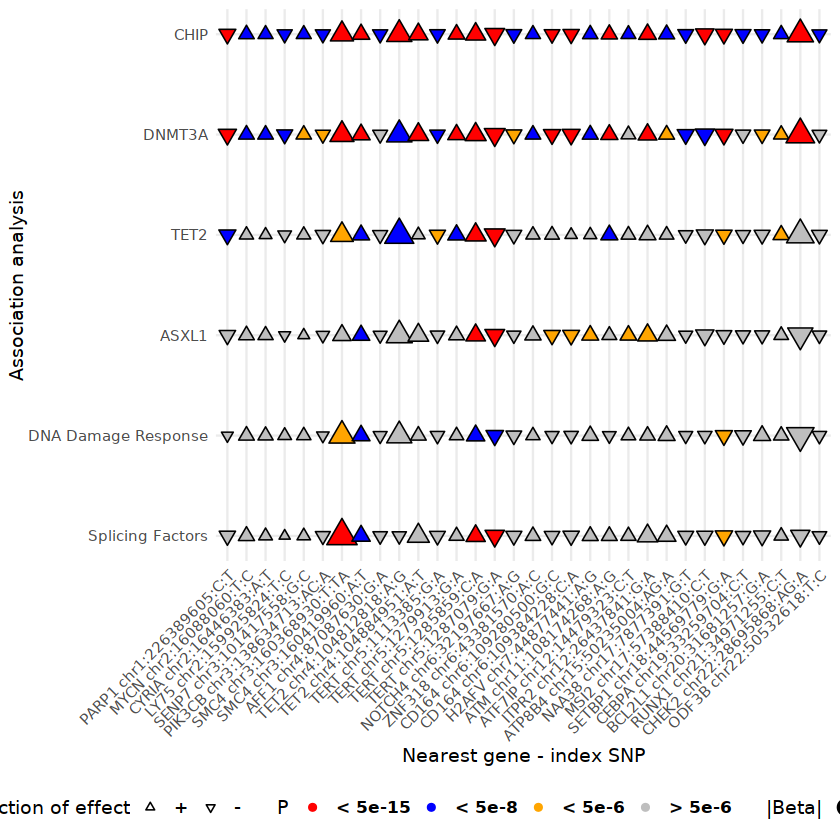

In [35]:
p5e8_snvs <- unique(chip_only$SNPID[chip_only$P<=5e-8 & chip_only$Trait=="CHIP"])

chip_only.p5e8 <- chip_only %>% 
  filter(SNPID %in% p5e8_snvs) 

ggplot(chip_only.p5e8, aes(x = GenVarID, y = Trait)) +
  geom_point(
    aes(
      size  = abs(BETA),        # size by absolute value of BETA
      fill  = color,            # factor with categories: "<5e-15", "<5e-8", etc.
      shape = direction         # "+" or "-" for triangles up/down
    ),
    color = "black"
  ) +
  # Manually define fill scale:
  scale_fill_manual(
    name = "P",
    breaks = c("<5e-15", "<5e-8", "<5e-6", ">5e-6"),
    values = c("<5e-15" = "red", 
               "<5e-8"  = "blue", 
               "<5e-6"  = "orange", 
               ">5e-6"  = "grey"),
    labels = c(
      "<5e-15" = "< 5e-15",
      "<5e-8"  = "< 5e-8",
      "<5e-6"  = "< 5e-6",
      ">5e-6"  = "> 5e-6"
    ),
    guide = guide_legend(override.aes = list(color = c("red", "blue", "orange", "grey")))
  ) +
  scale_size_continuous(
    name  = "|Beta|",
    range = c(2,6)
  ) +
  scale_shape_manual(
    name   = "Direction of effect",
    values = c("+" = 24, "-" = 25)
  ) +
  labs(
    x = "Nearest gene - index SNP",
    y = "Association analysis"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.text = element_text(size = 10, face = "bold")
  ) + # Reduce vertical spacing between rows (y-axis categories)
    scale_y_discrete(expand = expansion(mult = c(0.05, 0.05)))

In [36]:
png(file = "multiCHIP_vs_others.MCPS.broad.png", 
    width = 12, height = 12, units= "in", 
    res=300, pointsize = 4)

  ggplot(chip_only.p5e8, aes(x = GenVarID, y = Trait)) +
  geom_point(
    aes(
      size  = abs(BETA),        # size by absolute value of BETA
      fill  = color,            # factor with categories: "<5e-15", "<5e-8", etc.
      shape = direction         # "+" or "-" for triangles up/down
    ),
    color = "black"
  ) +
  # Manually define fill scale:
  scale_fill_manual(
    name = "P",
    breaks = c("<5e-15", "<5e-8", "<5e-6", ">5e-6"),
    values = c("<5e-15" = "red", 
               "<5e-8"  = "blue", 
               "<5e-6"  = "orange", 
               ">5e-6"  = "grey"),
    labels = c(
      "<5e-15" = "< 5e-15",
      "<5e-8"  = "< 5e-8",
      "<5e-6"  = "< 5e-6",
      ">5e-6"  = "> 5e-6"
    ),
    guide = guide_legend(override.aes = list(color = c("red", "blue", "orange", "grey")))
  ) +
  scale_size_continuous(
    name  = "|Beta|",
    range = c(2,6)
  ) +
  scale_shape_manual(
    name   = "Direction of effect",
    values = c("+" = 24, "-" = 25)
  ) +
  labs(
    x = "Nearest gene - index SNP",
    y = "Association analysis"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.text = element_text(size = 10, face = "bold")
  ) + # Reduce vertical spacing between rows (y-axis categories)
    scale_y_discrete(expand = expansion(mult = c(0.05, 0.05)))

dev.off()



png 
  2

# Female vs Male: MultiCHIP

In [22]:
system("ls gwas_overlap/*.out.tsv| grep -E 'Female.ukb' |sort -V ", intern = TRUE)

system("ls gwas_overlap/*.out.tsv| grep -E 'Male.ukb' |sort -V ", intern = TRUE)

[1] "gwas_overlap/overlap_sr23.GWAMA.chr1_22.hasCH.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"     
[2] "gwas_overlap/overlap_sr24.GWAMA.chr1_22.hasCHvaf10.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"
[3] "gwas_overlap/overlap_sr31.GWAMA.chr1_22.hasDNMT3A.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv" 
[4] "gwas_overlap/overlap_sr38.GWAMA.chr1_22.hasTET2.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"   
[5] "gwas_overlap/overlap_sr42.GWAMA.chr1_22.hasASXL1.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"  
[6] "gwas_overlap/overlap_sr46.GWAMA.chr1_22.hasSF.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"     
[7] "gwas_overlap/overlap_sr49.GWAMA.chr1_22.hasDDR.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"

[1] "gwas_overlap/overlap_sr19.GWAMA.chr1_22.hasCH.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"     
[2] "gwas_overlap/overlap_sr27.GWAMA.chr1_22.hasCHvaf10.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"
[3] "gwas_overlap/overlap_sr29.GWAMA.chr1_22.hasDNMT3A.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv" 
[4] "gwas_overlap/overlap_sr39.GWAMA.chr1_22.hasTET2.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"   
[5] "gwas_overlap/overlap_sr41.GWAMA.chr1_22.hasASXL1.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"  
[6] "gwas_overlap/overlap_sr47.GWAMA.chr1_22.hasSF.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"     
[7] "gwas_overlap/overlap_sr48.GWAMA.chr1_22.hasDDR.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv"

In [24]:
library(data.table)

# Vector of file paths:
Female.multiCH_list <- c(
  'gwas_overlap/overlap_sr23.GWAMA.chr1_22.hasCH.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr24.GWAMA.chr1_22.hasCHvaf10.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr31.GWAMA.chr1_22.hasDNMT3A.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr38.GWAMA.chr1_22.hasTET2.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr42.GWAMA.chr1_22.hasASXL1.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr46.GWAMA.chr1_22.hasSF.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr49.GWAMA.chr1_22.hasDDR.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv')

Male.multiCH_list <- c(
  'gwas_overlap/overlap_sr19.GWAMA.chr1_22.hasCH.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr27.GWAMA.chr1_22.hasCHvaf10.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr29.GWAMA.chr1_22.hasDNMT3A.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr39.GWAMA.chr1_22.hasTET2.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr41.GWAMA.chr1_22.hasASXL1.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr47.GWAMA.chr1_22.hasSF.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv',
    'gwas_overlap/overlap_sr48.GWAMA.chr1_22.hasDDR.Male.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv')

# (Optional) Define a matching vector of 'traits' for each file
traits <- c(
  "CHIP",
  "Expanded CHIP",
  "DNMT3A",
  "TET2",
  "ASXL1",
  "DNA Damage Response",
  "Splicing Factors"
)

# Make a skeleton data frame with the proper columns:
chip_xx_xy <- data.frame(
  SNPID     = character(),
  EA        = character(),
  OtherA    = character(),
  EAF       = numeric(),
  BETA      = numeric(),
  SE        = numeric(),
  BETA_95L  = numeric(),
  BETA_95U  = numeric(),
  Z         = numeric(),
  P         = numeric(),
  min_neg_log10 = numeric(),
  Q_stat    = numeric(),
  Q_P       = numeric(),
  I2        = numeric(),
  N_studies = numeric(),
  N         = numeric(),
  Direction = character(),
  Trait     = character(),
  ANC       = character(), 
  stringsAsFactors = FALSE
)
##
# ANC vector for the loop
ANC <- c("Female", "Male")

# Loop over "Female" and "Male"
for (k in seq_along(ANC)) {
  # Select the appropriate file list
  if (ANC[k] == "Female") {
    my_list <- Female.multiCH_list
  } else {
    my_list <- Male.multiCH_list
  }
 # Loop over each file in the chosen list
  for (i in seq_along(my_list)) {
    cat("Reading file:", my_list[i], "\n")
    
    d <- fread(my_list[i], header = FALSE, sep = "\t")
      
  # Assign column names to match your specification
  names(d) <- c(
    "SNPID", "EA", "OtherA", "EAF", "BETA", "SE", "BETA_95L", "BETA_95U",
    "Z", "P", "min_neg_log10", "Q_stat", "Q_P", "I2", "N_studies", "N", 
    "Direction"
  )
  
    # Fill Trait & ANC
    # Only use 'traits' if lengths match
    if (exists("traits") && length(traits) == length(my_list)) {
      d$Trait <- traits[i]
    } else {
      d$Trait <- NA
    }
    d$ANC <- ANC[k]
    
    # Append to final data frame
    chip_xx_xy <- rbind(chip_xx_xy, d)
    
    cat("Current rows in chip_xx_xy:", nrow(chip_xx_xy), "\n\n")
  }
}

# Final check
str(chip_xx_xy)

Reading file: gwas_overlap/overlap_sr23.GWAMA.chr1_22.hasCH.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv 
Current rows in chip_xx_xy: 88 

Reading file: gwas_overlap/overlap_sr24.GWAMA.chr1_22.hasCHvaf10.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv 
Current rows in chip_xx_xy: 176 

Reading file: gwas_overlap/overlap_sr31.GWAMA.chr1_22.hasDNMT3A.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv 
Current rows in chip_xx_xy: 264 

Reading file: gwas_overlap/overlap_sr38.GWAMA.chr1_22.hasTET2.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv 
Current rows in chip_xx_xy: 352 

Reading file: gwas_overlap/overlap_sr42.GWAMA.chr1_22.hasASXL1.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv 
Current rows in chip_xx_xy: 440 

Reading file: gwas_overlap/overlap_sr46.GWAMA.chr1_22.hasSF.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv 
Current rows in chip_xx_xy: 528 

Reading file: gwas_overlap/overlap_sr49.GWAMA.chr1_22.hasDDR.Female.ukbb450k_AoU250k_TOPMed72k_MGBB53k.out.tsv 
Curre

In [26]:
table(chip_xx_xy$ANC, chip_xx_xy$Trait)

        
         ASXL1 CHIP DNA Damage Response DNMT3A Expanded CHIP Splicing Factors
  Female    88   88                  88     88            88               88
  Male      88   88                  88     88            88               88
        
         TET2
  Female   88
  Male     88

In [9]:
xx.chip_only <- merge(xx.chip_overlap, chip, by.x="SNPID", by.y="V1")
str(xx.chip_only)
head(xx.chip_only)

# Create a column for color based on p-value thresholds  ####
xx.chip_only$color <- factor(ifelse(xx.chip_only$P<5e-15,
                          "<5e-15", 
                          ifelse(xx.chip_only$P<5e-8 & xx.chip_only$P>=5e-15,
                                 "<5e-8", 
                                 ifelse(xx.chip_only$P<5e-6 & xx.chip_only$P>=5e-8,
                                 "<5e-6", ">5e-6")) ))
                          
# # Create a column for shape based on direction
xx.chip_only$shape <- ifelse(xx.chip_only$Z>0, 24, 25)  # 24 = upfaced triangle, 25 = downfaced triangle
xx.chip_only$direction <- ifelse(xx.chip_only$Z>0, "+", "-")  # 
#chip_only$shape <- ifelse(chip_only$direction == "+", 24, 25)  # 24 = upfaced triangle, 25 = downfaced triangle
head(xx.chip_only)

table(xx.chip_only$color, exclude = NULL)
table(xx.chip_only$P<5e-15)
summary(scale(xx.chip_only$Z))


Classes 'data.table' and 'data.frame':	252 obs. of  20 variables:
 $ SNPID        : chr  "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" ...
 $ EA           : chr  "G" "G" "G" "G" ...
 $ OtherA       : chr  "A" "A" "A" "A" ...
 $ EAF          : num  0.398 0.398 0.397 0.397 0.396 ...
 $ BETA         : num  0.0784 0.0867 0.1024 0.09 0.045 ...
 $ SE           : num  0.00956 0.01274 0.0124 0.02149 0.03661 ...
 $ BETA_95L     : num  0.0596 0.0617 0.0781 0.0479 -0.0267 ...
 $ BETA_95U     : num  0.0971 0.1116 0.1267 0.1322 0.1168 ...
 $ Z            : num  8.19 6.8 8.26 4.19 1.23 ...
 $ P            : num  2.67e-16 1.07e-11 1.60e-16 2.83e-05 2.19e-01 ...
 $ min_neg_log10: num  15.57 10.97 15.8 4.55 0.66 ...
 $ Q_stat       : num  2.8 3.395 2.755 0.402 2.453 ...
 $ Q_P          : num  0.423 0.335 0.431 0.94 0.484 ...
 $ I2           : num  0 0.116 0 0 0 ...
 $ N_studies    : int  4 4 4 4 4 4 4 4 4 4 ...
 $ N            : int  443114 440126 432108 422182

SNPID,EA,OtherA,EAF,BETA,SE,BETA_95L,BETA_95U,Z,P,min_neg_log10,Q_stat,Q_P,I2,N_studies,N,Direction,Trait,Genes,GenVarID
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr11:108174268:A:G,G,A,0.397762,0.078364,0.009564,0.059617,0.097110,8.193315,2.67000e-16,15.573006,2.800152,0.423475,0.000000,4,443114,++++,XX CHIP,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.397648,0.086665,0.012741,0.061693,0.111637,6.802161,1.07000e-11,10.971050,3.395495,0.334571,0.116476,4,440126,++++,XX Expanded CHIP,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.397297,0.102379,0.012402,0.078072,0.126686,8.255265,1.60000e-16,15.797192,2.755434,0.430889,0.000000,4,432108,++++,XX DNMT3A,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.396707,0.090038,0.021491,0.047916,0.132161,4.189583,2.83000e-05,4.548624,0.401862,0.939858,0.000000,4,422182,++++,XX TET2,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.396450,0.045046,0.036612,-0.026713,0.116804,1.230363,2.18541e-01,0.660468,2.453242,0.483801,0.000000,4,418982,++-+,XX ASXL1,ATM,ATM chr11:108174268:A:G
chr11:108174268:A:G,G,A,0.396385,0.015819,0.064289,-0.110188,0.141825,0.246057,8.05633e-01,0.093863,1.214656,0.749491,0.000000,4,417892,+--+,XX DNA Damage Response,ATM,ATM chr11:108174268:A:G


SNPID,EA,OtherA,EAF,BETA,SE,BETA_95L,BETA_95U,Z,P,...,I2,N_studies,N,Direction,Trait,Genes,GenVarID,color,shape,direction
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>
chr11:108174268:A:G,G,A,0.397762,0.078364,0.009564,0.059617,0.097110,8.193315,2.67000e-16,...,0.000000,4,443114,++++,XX CHIP,ATM,ATM chr11:108174268:A:G,<5e-15,24,+
chr11:108174268:A:G,G,A,0.397648,0.086665,0.012741,0.061693,0.111637,6.802161,1.07000e-11,...,0.116476,4,440126,++++,XX Expanded CHIP,ATM,ATM chr11:108174268:A:G,<5e-8,24,+
chr11:108174268:A:G,G,A,0.397297,0.102379,0.012402,0.078072,0.126686,8.255265,1.60000e-16,...,0.000000,4,432108,++++,XX DNMT3A,ATM,ATM chr11:108174268:A:G,<5e-15,24,+
chr11:108174268:A:G,G,A,0.396707,0.090038,0.021491,0.047916,0.132161,4.189583,2.83000e-05,...,0.000000,4,422182,++++,XX TET2,ATM,ATM chr11:108174268:A:G,>5e-6,24,+
chr11:108174268:A:G,G,A,0.396450,0.045046,0.036612,-0.026713,0.116804,1.230363,2.18541e-01,...,0.000000,4,418982,++-+,XX ASXL1,ATM,ATM chr11:108174268:A:G,>5e-6,24,+
chr11:108174268:A:G,G,A,0.396385,0.015819,0.064289,-0.110188,0.141825,0.246057,8.05633e-01,...,0.000000,4,417892,+--+,XX DNA Damage Response,ATM,ATM chr11:108174268:A:G,>5e-6,24,+



<5e-15  <5e-6  <5e-8  >5e-6 
    23     21     20    188 


FALSE  TRUE 
  229    23 

       V1           
 Min.   :-4.129105  
 1st Qu.:-0.533344  
 Median :-0.002445  
 Mean   : 0.000000  
 3rd Qu.: 0.480787  
 Max.   : 4.346405  

In [10]:
table(xx.chip_only$Trait)


              XX ASXL1                XX CHIP XX DNA Damage Response 
                    36                     36                     36 
             XX DNMT3A       XX Expanded CHIP    XX Splicing Factors 
                    36                     36                     36 
               XX TET2 
                    36 

In [11]:
xx.chip_only$Trait <- ordered(xx.chip_only$Trait,
                           levels = paste0("XX",c("CHIP","Expanded CHIP","DNMT3A",
                                      "TET2","ASXL1",
                                      "DNA Damage Response","Splicing Factors")))

str(xx.chip_only)
str(xx.chip_only$Trait)


xx.chip_only$Trait <- ordered(xx.chip_only$Trait,
                           levels = c("Splicing Factors", "DNA Damage Response",
                                      "ASXL1","TET2","DNMT3A","Expanded CHIP","CHIP"))

str(xx.chip_only)
str(xx.chip_only$Trait)


## 

xx.chip_only$GenVarID <- ordered(xx.chip_only$GenVarID,
                           levels = chip$GenVarID)

str(xx.chip_only)

Classes 'data.table' and 'data.frame':	252 obs. of  23 variables:
 $ SNPID        : chr  "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" "chr11:108174268:A:G" ...
 $ EA           : chr  "G" "G" "G" "G" ...
 $ OtherA       : chr  "A" "A" "A" "A" ...
 $ EAF          : num  0.398 0.398 0.397 0.397 0.396 ...
 $ BETA         : num  0.0784 0.0867 0.1024 0.09 0.045 ...
 $ SE           : num  0.00956 0.01274 0.0124 0.02149 0.03661 ...
 $ BETA_95L     : num  0.0596 0.0617 0.0781 0.0479 -0.0267 ...
 $ BETA_95U     : num  0.0971 0.1116 0.1267 0.1322 0.1168 ...
 $ Z            : num  8.19 6.8 8.26 4.19 1.23 ...
 $ P            : num  2.67e-16 1.07e-11 1.60e-16 2.83e-05 2.19e-01 ...
 $ min_neg_log10: num  15.57 10.97 15.8 4.55 0.66 ...
 $ Q_stat       : num  2.8 3.395 2.755 0.402 2.453 ...
 $ Q_P          : num  0.423 0.335 0.431 0.94 0.484 ...
 $ I2           : num  0 0.116 0 0 0 ...
 $ N_studies    : int  4 4 4 4 4 4 4 4 4 4 ...
 $ N            : int  443114 440126 432108 422182

In [12]:
# library(ggplot2)

# 1. Ensure 'color' is a factor with the levels you intend to plot
xx.chip_only$color <- factor(
  xx.chip_only$color,
  levels = c("<5e-15", "<5e-8", "<5e-6", ">5e-6")
)

png(file = "multiCHIP_vs_others.v3.png", 
    width = 12, height = 12, 
    units = "in", res = 300, pointsize = 4)

ggplot(xx.chip_only, aes(x = GenVarID, y = Trait)) +
  geom_point(
    aes(
      size  = BETA, 
      fill  = color,      # Map fill to the 'color' factor
      shape = direction   # '+' or '-' for triangles up/down
    ),
    color = "black"       # Outline color for the shape
  ) +
  # Discrete fill scale for P-value categories
  scale_fill_manual(
    name = "P",           # Legend title for fill
    values = c(
      "<5e-15" = "red", 
      "<5e-8"  = "blue", 
      "<5e-6"  = "orange", 
      ">5e-6"  = "grey"
    ),
    breaks = c("<5e-15", "<5e-8", "<5e-6", ">5e-6"),  
    drop = FALSE  # Keep categories even if no points in some bin
  ) +
  # Map BETA to size
  scale_size_continuous(range = c(1, 5)) +
  # Discrete shape scale for direction
  scale_shape_manual(
    name = "Direction of effect",
    values = c("+" = 24, "-" = 25)  # Up/down triangles
  ) +
  labs(
    x    = "Nearest gene - index SNP",
    y    = "Association analysis",
    size = "BETA"    # The size legend label
    # No need to specify fill= or shape= here,
    # we handle those in the scale_*_manual() calls
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

dev.off()


png 
  2